# Weekly Sentiment Score - Scoring Generator

The previous notebooks establish the prediction source and evaluate its behavior. This notebook starts from that decision and focuses only on the next step: converting article-level predictions into a weekly sentiment index.

The new work here is the scoring layer. Instead of counting labels, the index uses the probability spread between POSITIVE and NEGATIVE for every article. That keeps weak and strong predictions distinct: an article with high positive probability contributes more than an article that barely crosses the POSITIVE decision boundary. NEUTRAL still matters indirectly because it reduces the probability mass available to POSITIVE and NEGATIVE.

The second new step is historical mean adjustment. Financial news is not naturally balanced around zero, even after fine-tuning. The raw weekly average is therefore shifted by its long-run mean so that zero represents the historical baseline of this corpus. A positive final score means the week was more optimistic than usual; a negative final score means it was more pessimistic than usual.

### Flow
1. Load the current fine-tuned predictions.
2. Convert article probabilities into per-article sentiment contributions.
3. Aggregate contributions by week and adjust by the historical mean.
4. Inspect the adjusted time series and moving averages.
5. Export the final weekly score file.


## 1. Setup

This section defines the minimal scoring toolkit: paths, plotting settings and two helpers. `prepare_sentiment_frame` normalizes model scores into POSITIVE, NEGATIVE and NEUTRAL probabilities, then creates the article-level fields used by the weekly index.

The notebook deliberately does not re-evaluate model quality. F1, class behavior and bias correction are handled in the previous notebooks; here the concern is how to turn the selected model output into a stable weekly time series.


In [7]:
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FINETUNED_RESULTS_PATH = PROJECT_ROOT / "output/finetuned_model_classified.jsonl"
COLORS = {"POSITIVE": "#27AE60", "NEGATIVE": "#E74C3C", "NEUTRAL": "#3498DB"}

def week_key_to_date(wk: str) -> pd.Timestamp:
    year, week = wk.split("-W")
    return pd.Timestamp.fromisocalendar(int(year), int(week), 1)

def prepare_sentiment_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    score_sum = frame["score_positive"] + frame["score_negative"] + frame["score_neutral"]
    frame["pos"] = frame["score_positive"] / score_sum
    frame["neg"] = frame["score_negative"] / score_sum
    frame["neu"] = frame["score_neutral"] / score_sum
    frame["confidence"] = frame.apply(
        lambda r: {"POSITIVE": r["pos"], "NEGATIVE": r["neg"], "NEUTRAL": r["neu"]}[r["predicted_label"]], axis=1
    )
    frame["net_score"] = frame["pos"] - frame["neg"]
    frame["year"] = frame["week_key"].str[:4].astype(int)
    frame.loc[frame["year"] == 2026, "year"] = 2025
    return frame


## 2. Data Loading

The input is `output/finetuned_model_classified.jsonl`, the latest article-level production output from the fine-tuned model. Each row is transformed into normalized probabilities and a net score `P(POSITIVE) - P(NEGATIVE)`.

The printed class distribution is only a scoring sanity check. It verifies that the file is readable, that the expected labels are present and that the corpus still has the cautious financial-news profile seen in the earlier notebooks. The interpretation of model quality is intentionally not repeated here.


In [8]:
df_raw = pd.read_json(FINETUNED_RESULTS_PATH, lines=True)
df = prepare_sentiment_frame(df_raw)
df["published_at"] = pd.to_datetime(df["published_at"], format="ISO8601", utc=True)
df["week_num"] = df["week_key"].str.extract(r"W(\d+)").astype(int)
df["week_start"] = df["week_key"].map(week_key_to_date)
df = df[df["year"].between(2016, 2025)].copy().reset_index(drop=True)

n_pos = (df["predicted_label"] == "POSITIVE").sum()
n_neg = (df["predicted_label"] == "NEGATIVE").sum()
n_neu = (df["predicted_label"] == "NEUTRAL").sum()
total = len(df)
print(f"Total: {total:,}  |  POSITIVE: {n_pos:,} ({n_pos/total:.1%})  |  "
      f"NEGATIVE: {n_neg:,} ({n_neg/total:.1%})  |  NEUTRAL: {n_neu:,} ({n_neu/total:.1%})")
print(f"Interval: {df['published_at'].min().date()} → {df['published_at'].max().date()}")
df[["predicted_label", "pos", "neg", "neu", "net_score", "week_key"]].head(5)


Total: 56,498  |  POSITIVE: 11,197 (19.8%)  |  NEGATIVE: 23,748 (42.0%)  |  NEUTRAL: 21,553 (38.1%)
Interval: 2016-01-04 → 2025-12-31


,predicted_label,pos,neg,neu,net_score,week_key
0,NEGATIVE,0.086671,0.870722,0.042607,-0.784051,2016-W01
1,NEUTRAL,0.059674,0.082826,0.857500,-0.023152,2016-W01
2,POSITIVE,0.367486,0.344343,0.288171,0.023143,2016-W01
3,NEGATIVE,0.044776,0.920092,0.035132,-0.875316,2016-W01
4,NEUTRAL,0.121549,0.166840,0.711611,-0.045291,2016-W01


## 3. Weekly Score and Historical Mean Adjustment

The weekly score starts at the article level. Each article contributes:

`contribution = P(POSITIVE) - P(NEGATIVE)`

The weekly raw score is the average contribution among all articles in that ISO week. This probability-weighted approach is more informative than counting predicted labels because it preserves prediction intensity. Two articles with the same label can contribute differently if one is much more confidently positive or negative.

After weekly aggregation, the historical mean of the raw weekly series is subtracted from every week. This is the key scoring adjustment. It changes the interpretation from absolute polarity to deviation from the corpus baseline:

- `weekly_score > 0`: sentiment above the historical average;
- `weekly_score = 0`: sentiment near the corpus baseline;
- `weekly_score < 0`: sentiment below the historical average.

This adjustment does not hide negative periods. It makes downturns and recoveries easier to compare because the reference line represents normal behavior for this specific financial-news corpus.


In [9]:
df["contrib"] = df["pos"] - df["neg"]

ws = (
    df.groupby(["week_key", "week_start"])
    .agg(raw_score=("contrib", "mean"))
    .reset_index()
    .sort_values("week_start")
    .reset_index(drop=True)
)

mu_hist = ws["raw_score"].mean()
sigma_hist = ws["raw_score"].std()
ws["weekly_score"] = ws["raw_score"] - mu_hist

ws["ma4_score"] = ws["weekly_score"].rolling(4, center=True, min_periods=2).mean()
ws["ma13_score"] = ws["weekly_score"].rolling(13, center=True, min_periods=6).mean()
ws["ma52_score"] = ws["weekly_score"].rolling(52, center=True, min_periods=26).mean()

print("=== Raw Score (before centering) ===")
print(f"  Mean  : {mu_hist:+.4f}  <- subtracted as baseline")
print(f"  Std   : {sigma_hist:.4f}")
print(f"  Min   : {ws['raw_score'].min():+.4f}   Max: {ws['raw_score'].max():+.4f}")
print(f"  % weeks > 0 : {(ws['raw_score'] > 0).mean():.1%}\n")

print("=== Weekly Score (after centering) ===")
print(f"  Mean  : {ws['weekly_score'].mean():+.6f}  (exactly 0 by construction)")
print(f"  Std   : {ws['weekly_score'].std():.4f}")
print(f"  Min   : {ws['weekly_score'].min():+.4f}   Max: {ws['weekly_score'].max():+.4f}")
print(f"  % weeks > 0 (weekly) : {(ws['weekly_score'] > 0).mean():.1%}")
print(f"  % weeks > 0 (MA4)    : {(ws['ma4_score'].dropna() > 0).mean():.1%}")
print(f"  % weeks > 0 (MA13)   : {(ws['ma13_score'].dropna() > 0).mean():.1%}")
print(f"  % weeks > 0 (MA52)   : {(ws['ma52_score'].dropna() > 0).mean():.1%}")
print(f"\n  Historical mean subtracted: {mu_hist:+.4f}")

dates = ws["week_start"]


=== Raw Score (before centering) ===
  Mean  : -0.1424  <- subtracted as baseline
  Std   : 0.1262
  Min   : -0.5572   Max: +0.2698
  % weeks > 0 : 13.4%

=== Weekly Score (after centering) ===
  Mean  : +0.000000  (exactly 0 by construction)
  Std   : 0.1262
  Min   : -0.4149   Max: +0.4122
  % weeks > 0 (weekly) : 48.1%
  % weeks > 0 (MA4)    : 47.5%
  % weeks > 0 (MA13)   : 48.7%
  % weeks > 0 (MA52)   : 54.6%

  Historical mean subtracted: -0.1424


## 4. Historical Sentiment Index

This chart is the final visual check before export. The weekly adjusted score captures event-level shocks, while moving averages make the signal easier to read across different horizons.

The 13-week moving average is the main trend line because it approximates a quarterly view and smooths noisy single-week jumps without erasing regime changes. Event annotations are included as historical reference points to make large movements easier to audit against recognizable market and macroeconomic moments.


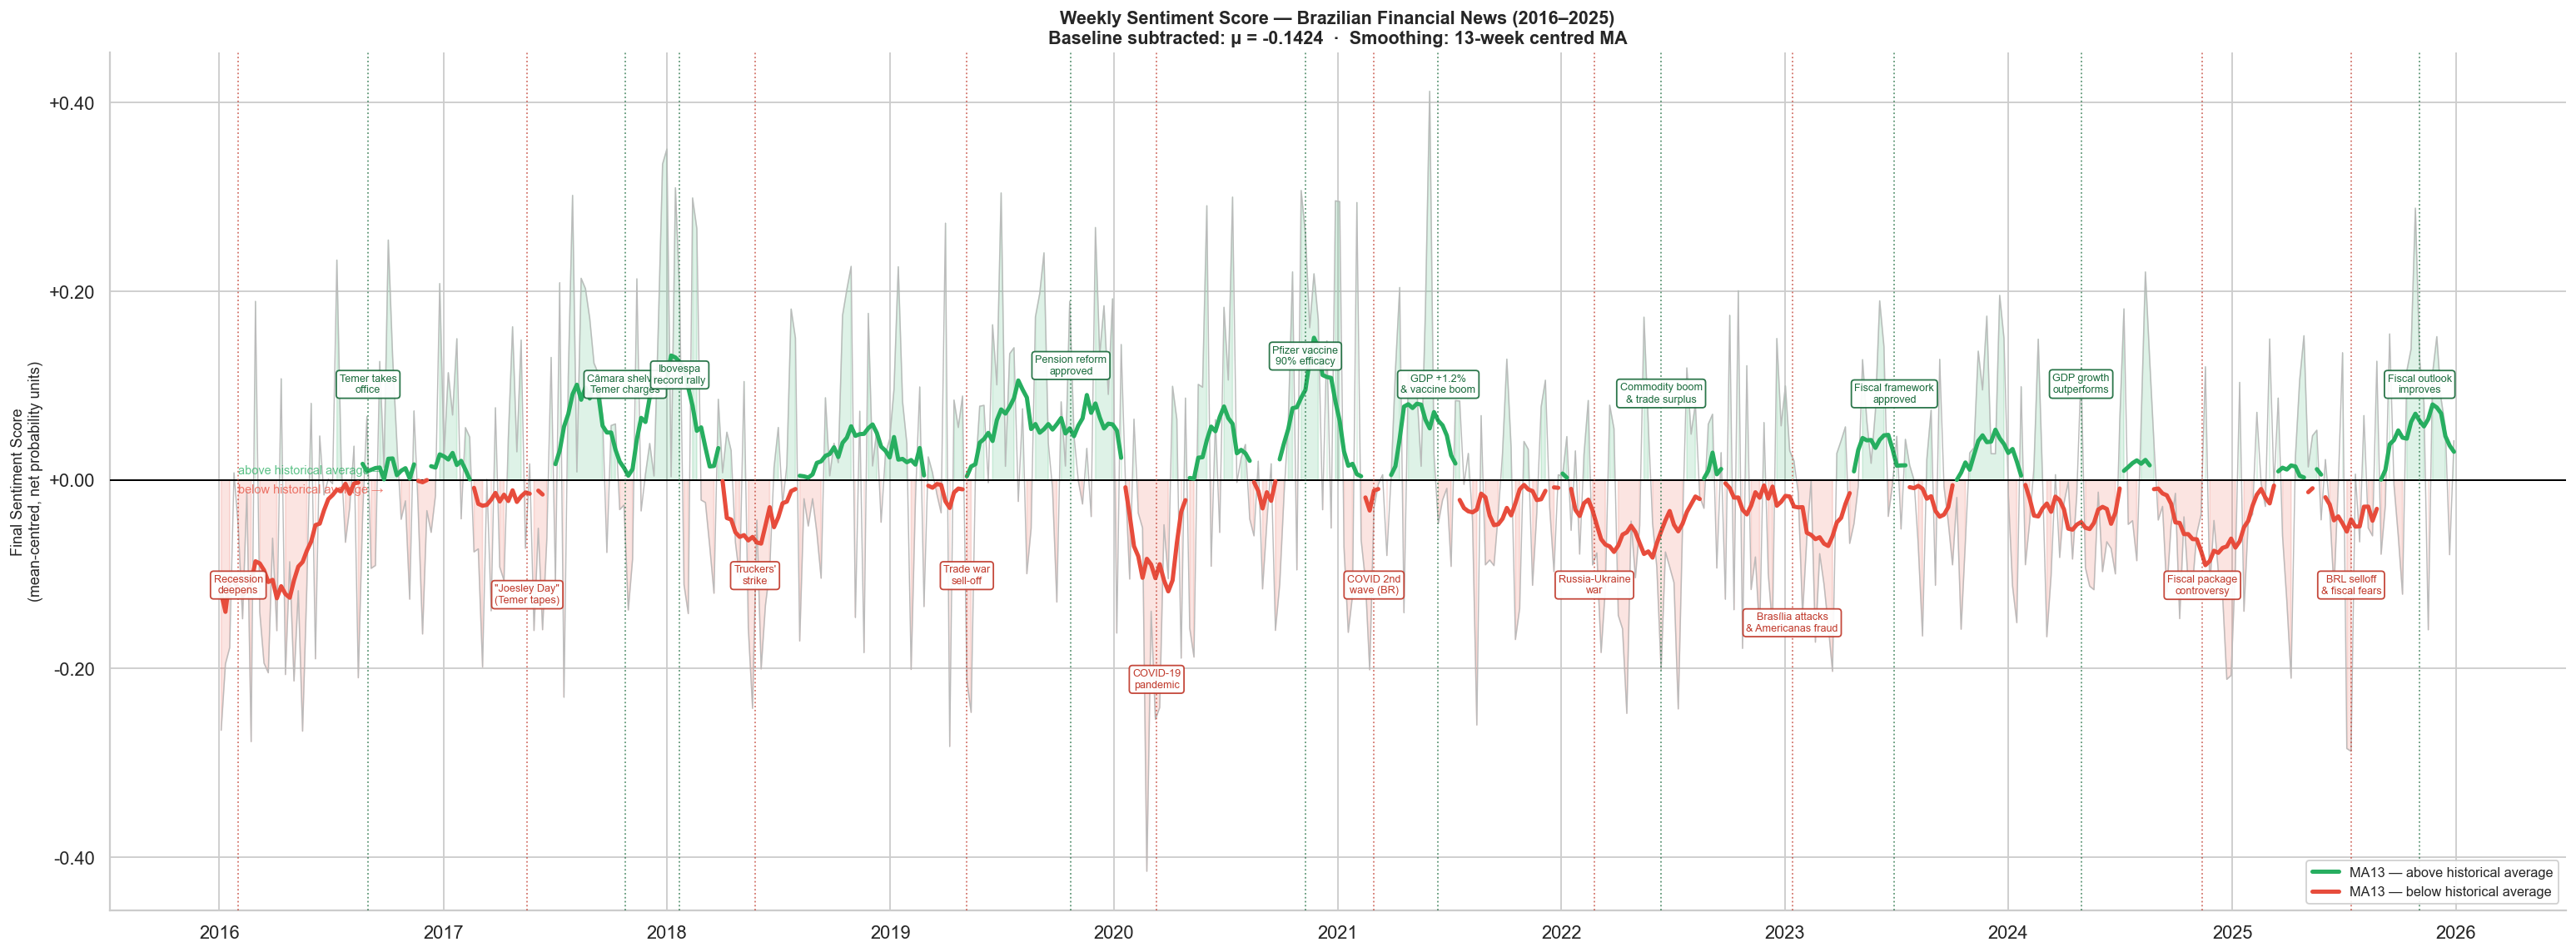

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Historical Weekly Sentiment Score — Full chart (2016–2025)
# ─────────────────────────────────────────────────────────────────────────────
#
# Single panel: weekly score (filled area) + 13-week MA (coloured line)
# The MA line is green when above zero (above-average sentiment) and red
# when below, making trend reversals immediately legible.
#
# EVENTS dict:  (label, y_offset, colour, va)
#   Exactly 2 events per year (2016–2025): one positive peak and one negative
#   trough, anchored to the most significant scoring excursions each year.
#   Colours: dark red (#C0392B) for crises/troughs,
#            dark green (#1A6B3C) for rallies/peaks.

EVENTS = {
    # ── 2016 ─────────────────────────────────────────────────────────────────
    "2016-02-01": ("Recession\ndeepens",                   -0.10, "#C0392B", "top"),
    "2016-08-31": ("Temer takes\noffice",                   0.09, "#1A6B3C", "bottom"),
    # ── 2017 ─────────────────────────────────────────────────────────────────
    "2017-05-18": ('"Joesley Day"\n(Temer tapes)',          -0.11, "#C0392B", "top"),
    "2017-10-25": ("Câmara shelves\nTemer charges",          0.09, "#1A6B3C", "bottom"),
    # ── 2018 ─────────────────────────────────────────────────────────────────
    "2018-01-22": ("Ibovespa\nrecord rally",                 0.10, "#1A6B3C", "bottom"),
    "2018-05-25": ("Truckers'\nstrike",                     -0.09, "#C0392B", "top"),
    # ── 2019 ─────────────────────────────────────────────────────────────────
    "2019-05-06": ("Trade war\nsell-off",                   -0.09, "#C0392B", "top"),
    "2019-10-23": ("Pension reform\napproved",               0.11, "#1A6B3C", "bottom"),
    # ── 2020 ─────────────────────────────────────────────────────────────────
    "2020-03-11": ("COVID-19\npandemic",                    -0.20, "#C0392B", "top"),
    "2020-11-09": ("Pfizer vaccine\n90% efficacy",           0.12, "#1A6B3C", "bottom"),
    # ── 2021 ─────────────────────────────────────────────────────────────────
    "2021-03-01": ("COVID 2nd\nwave (BR)",                  -0.10, "#C0392B", "top"),
    "2021-06-14": ("GDP +1.2%\n& vaccine boom",              0.09, "#1A6B3C", "bottom"),
    # ── 2022 ─────────────────────────────────────────────────────────────────
    "2022-02-24": ("Russia-Ukraine\nwar",                   -0.10, "#C0392B", "top"),
    "2022-06-13": ("Commodity boom\n& trade surplus",        0.08, "#1A6B3C", "bottom"),
    # ── 2023 ─────────────────────────────────────────────────────────────────
    "2023-01-13": ("Brasília attacks\n& Americanas fraud",  -0.14, "#C0392B", "top"),
    "2023-06-29": ("Fiscal framework\napproved",             0.08, "#1A6B3C", "bottom"),
    # ── 2024 ─────────────────────────────────────────────────────────────────
    "2024-04-29": ("GDP growth\noutperforms",                0.09, "#1A6B3C", "bottom"),
    "2024-11-13": ("Fiscal package\ncontroversy",           -0.10, "#C0392B", "top"),
    # ── 2025 ─────────────────────────────────────────────────────────────────
    "2025-07-14": ("BRL selloff\n& fiscal fears",           -0.10, "#C0392B", "top"),
    "2025-11-03": ("Fiscal outlook\nimproves",               0.09, "#1A6B3C", "bottom"),
}

fig, ax = plt.subplots(figsize=(24, 9))

raw = ws["weekly_score"].values
ma  = ws["ma13_score"].values

# Filled background areas
ax.fill_between(dates, raw, 0,
                where=(raw >= 0), color=COLORS["POSITIVE"], alpha=0.15, zorder=1)
ax.fill_between(dates, raw, 0,
                where=(raw <  0), color=COLORS["NEGATIVE"], alpha=0.15, zorder=1)

# Weekly raw score — thin grey line
ax.plot(dates, raw, color="#BBBBBB", linewidth=0.8, zorder=2)

# MA13 coloured by sign
pos_ma = np.where(ma >= 0, ma, np.nan)
neg_ma = np.where(ma <  0, ma, np.nan)
ax.plot(dates, pos_ma, color=COLORS["POSITIVE"], linewidth=2.8, zorder=4,
        label="MA13 — above historical average")
ax.plot(dates, neg_ma, color=COLORS["NEGATIVE"], linewidth=2.8, zorder=4,
        label="MA13 — below historical average")

ax.axhline(0, color="black", linewidth=1.1, zorder=3)

# ── Event annotations ─────────────────────────────────────────────────────
for date_str, (label, y_off, ec, va) in EVENTS.items():
    ev_date = pd.Timestamp(date_str)
    ax.axvline(ev_date, color=ec, linewidth=1.0, linestyle=":", alpha=0.70, zorder=5)
    ax.text(ev_date, y_off, label,
            fontsize=7, color=ec, ha="center",
            va="bottom" if va == "bottom" else "top",
            zorder=20, clip_on=False,
            bbox=dict(fc="white", ec=ec, alpha=0.92, pad=1.5,
                      boxstyle="round,pad=0.3"))

# Year grid lines
for year in range(2016, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="lightgray",
               linewidth=0.5, alpha=0.5, zorder=0)

# Zero-line labels
ax.text(dates.iloc[4],  0.004, "above historical average →",
        fontsize=8, color=COLORS["POSITIVE"], va="bottom", alpha=0.75)
ax.text(dates.iloc[4], -0.004, "below historical average →",
        fontsize=8, color=COLORS["NEGATIVE"], va="top", alpha=0.75)

ax.set_ylabel("Final Sentiment Score\n(mean-centred, net probability units)", fontsize=10)
ax.set_title(
    "Weekly Sentiment Score — Brazilian Financial News (2016–2025)\n"
    f"Baseline subtracted: μ = {mu_hist:+.4f}  ·  Smoothing: 13-week centred MA",
    fontsize=12, fontweight="bold"
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()


## 5. Export

The export step writes the weekly index to `output/weekly_sentiment_scores.csv`. This file is the compact artifact intended for downstream analysis: one row per week, with the final adjusted score and the supporting fields needed to audit it.

The exported score should be read as a relative sentiment index. It answers: was this week more positive or more negative than the historical norm of the corpus? It should not be interpreted as a direct probability, nor as a simple count of positive and negative labels.


In [11]:
labels_ = ["Muito Negativo", "Negativo", "Neutro", "Positivo", "Muito Positivo"]
classification_bins = {
    "weekly_score": [-np.inf, -0.15, -0.05, 0.05, 0.15, np.inf],
    "ma4_score": [-np.inf, -0.09, -0.03, 0.03, 0.09, np.inf],
    "ma13_score": [-np.inf, -0.06, -0.02, 0.02, 0.06, np.inf],
    "ma52_score": [-np.inf, -0.03, -0.01, 0.01, 0.03, np.inf],
}

ws["weekly_classification"] = pd.cut(
    ws["weekly_score"], bins=classification_bins["weekly_score"], labels=labels_
)
ws["ma4_classification"] = pd.cut(
    ws["ma4_score"], bins=classification_bins["ma4_score"], labels=labels_
)
ws["ma13_classification"] = pd.cut(
    ws["ma13_score"], bins=classification_bins["ma13_score"], labels=labels_
)
ws["ma52_classification"] = pd.cut(
    ws["ma52_score"], bins=classification_bins["ma52_score"], labels=labels_
)

ws[
    [
        "week_key",
        "weekly_score",
        "ma4_score",
        "ma13_score",
        "ma52_score",
        "weekly_classification",
        "ma4_classification",
        "ma13_classification",
        "ma52_classification",
    ]
].head()

,week_key,weekly_score,ma4_score,ma13_score,ma52_score,weekly_classification,ma4_classification,ma13_classification,ma52_classification
0,2016-W01,-0.265362,-0.230213,-0.120136,-0.102268,Muito Negativo,Muito Negativo,Muito Negativo,Muito Negativo
1,2016-W02,-0.195065,-0.212703,-0.139794,-0.098631,Muito Negativo,Muito Negativo,Muito Negativo,Muito Negativo
2,2016-W03,-0.177682,-0.157601,-0.103208,-0.086782,Muito Negativo,Muito Negativo,Muito Negativo,Muito Negativo
3,2016-W04,0.007706,-0.103962,-0.106855,-0.083085,Neutro,Muito Negativo,Muito Negativo,Muito Negativo
4,2016-W05,-0.050808,-0.091978,-0.114790,-0.082517,Negativo,Muito Negativo,Muito Negativo,Muito Negativo


## Output Columns

The output keeps both the final index and diagnostic context. The main field is the adjusted `weekly_score`; the moving-average columns support trend analysis; the probability columns and article counts allow later checks on whether a weekly movement came from sentiment intensity, class mix or unusual publication volume.


In [12]:
OUTPUT_CSV = PROJECT_ROOT / "output/weekly_sentiment_scores.csv"

export_cols = [
    "week_key",
    "week_start",
    "weekly_score",
    "ma4_score",
    "ma13_score",
    "ma52_score",
    "weekly_classification",
    "ma4_classification",
    "ma13_classification",
    "ma52_classification",
]

ws[export_cols].to_csv(OUTPUT_CSV, index=False, float_format="%.6f")
print(f"Saved {len(ws)} weeks -> {OUTPUT_CSV}")

Saved 522 weeks -> c:\Users\lucas\Documents\Faculdade\tcc\sentimental-analisys\output\weekly_sentiment_scores.csv


## Final Summary

This notebook completes the workflow by turning the selected fine-tuned model output into a weekly sentiment index. The previous notebooks justify the model choice; this notebook defines the scoring rule and creates the exportable time series.

The final score is probability-weighted and historically centered. Probability weighting keeps prediction strength, while historical centering gives the zero line a practical meaning for Brazilian financial news. Positive values indicate weeks above the corpus baseline; negative values indicate weeks below it.

The exported CSV is therefore the final weekly artifact for downstream use: compact enough for analysis, but still accompanied by moving averages, article counts and probability diagnostics for auditability.
